In [1]:
from hcipy import *
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as ndimage
from matplotlib.animation import FFMpegWriter
from tqdm.notebook import tqdm
import astropy.io.fits as fits
from pathlib import Path, PosixPath
import math
from scipy.interpolate import interp1d
import scipy.integrate as integrate
from shackhartmann import MySquareShackHartmannWavefrontSensorOptics
from transmitted_power import transmitted_power
from csv import DictWriter

In [2]:
# some telescope parameters

telescope_diameter = 0.8 # [m]
focal_length = 5.6 #m
platescale = 206265 / focal_length # [arcsec / m]
fov_sci = 2 # arcsec

spider_width = 0.02 # [m] -- this is a guess
num_spiders = 4
central_obscuration = 0.1558 # [m]
central_obscuration_ratio = central_obscuration / telescope_diameter
area_aperture = math.pi*(telescope_diameter/2)**2 - math.pi*(central_obscuration/2)**2 - 0.5*(telescope_diameter-central_obscuration)*spider_width*num_spiders # m^2


In [3]:
# set some WFS parameters

num_lenslets = 8 # 10 corresponds to (D/r0)**2 at seeing = 1.25"
px_size = 24e-6 # [m] -- Armasuisse report cameras
px_scale = 0.75 # [arcsec / px]  -- want to be sensitive to seeing
fov_wfs = 5 # [arcsec] -- LEO size

px_per_subap = round(fov_wfs / px_scale, 0)

num_pupil_pixels = px_per_subap * num_lenslets 
pupil_diameter = telescope_diameter

In [4]:
# transmission loss parameters

n_telescope_mirrors = 3
n_ao_mirrors = 7

target_spectrum_file = Path('LEO_spectrum_mag5.fits') # can be .fits or .csv
telescope_coating_file = Path('protected_aluminium_ZimMAIN.csv') # wavelength in [µm]
ao_coating_file = Path('protected_aluminium_ZimMAIN.csv')

In [5]:
# make a telescope pupil

pupil_grid = make_pupil_grid(num_pupil_pixels, diameter=pupil_diameter)
pupil_aperture_generator = make_obstructed_circular_aperture(telescope_diameter, 
                                                             central_obscuration_ratio, 
                                                             num_spiders=num_spiders, 
                                                             spider_width=spider_width)
telescope_pupil = evaluate_supersampled(pupil_aperture_generator, pupil_grid, 4)

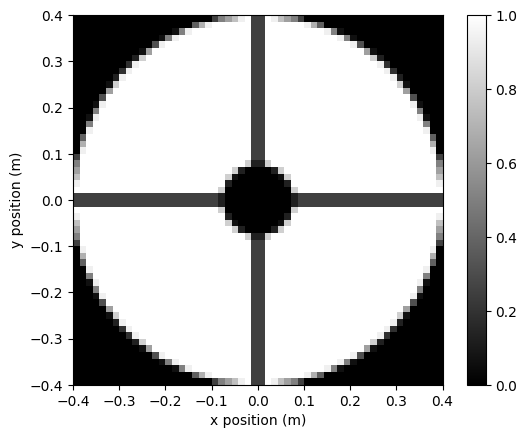

In [6]:
imshow_field(telescope_pupil, cmap='gray') 
plt.xlabel('x position (m)')
plt.ylabel('y position (m)')
plt.colorbar()
plt.show()

In [7]:
# make an atmosphere

seeing = 1 # [arcsec] @ 500nm (convention) 
outer_scale = 40 # [m]
tau0 = 0.01 # [s] 

fried_parameter = seeing_to_fried_parameter(seeing) # [m]
Cn_squared = Cn_squared_from_fried_parameter(fried_parameter, 500e-9)
velocity = 0.314 * fried_parameter / tau0 # this is a formula cited by various sources, not sure where the coefficient was born from

layer = InfiniteAtmosphericLayer(pupil_grid, Cn_squared, outer_scale, velocity)

In [8]:
# get target light

hdu = fits.open(target_spectrum_file)
target_wavelength, target_flux = hdu[1].data['WAVELENGTH'], hdu[1].data['FLUX'] # [angstroms], [FLAM = erg * s^-1 * cm^-2 * angstr^-1]
target_power = target_flux*area_aperture*1e4 # [erg * s^-1 * angstr^-1]

In [9]:
# reduce target light transmission due to surfaces in telescope and AO

wavelength_crop1, transmitted_power_telescope = transmitted_power(wavelength = target_wavelength, 
                                                                  in_power = target_power,
                                                                  transmission_file = telescope_coating_file,
                                                                  n_surfaces = n_telescope_mirrors)

wavelength_crop2, transmitted_power_ao = transmitted_power(wavelength = wavelength_crop1, 
                                                         in_power = transmitted_power_telescope,
                                                         transmission_file = ao_coating_file,
                                                         n_surfaces = n_ao_mirrors)

In [10]:
# make wavefronts for after propagation through telescope & AO surfaces

wavefronts_target = []
for i, wlen in enumerate(wavelength_crop2): 
    wf = Wavefront(telescope_pupil, wlen*1e-10) # HCIPy wavefronts take wavelengths in meters only!
    wf.total_power = transmitted_power_ao[i] # [erg * s^-1 * angstr^-1] 
    wavefronts_target.append(wf)
    
# make wavefront arrays
target_wlens = np.array([wf.wavelength for wf in wavefronts_target])
target_powers = np.array([wf.total_power for wf in wavefronts_target]) 

# split wavefronts for WFS and Science Camera

# WFS beam
wavelength_wfs = 5750e-10 # [m] -- central wavelength
wfs_bandwidth = 500e-10
wfs_beamsplit = 1 # 0 (no light into WFS) to 1 (all of the light into WFS)

# science beam
wavelength_sci = 4750e-10 # [m] -- central wavelength
sci_bandwidth = 1500e-10

# group wavefronts for WFS and science beam, respectively
wfs_min, wfs_max = wavelength_wfs - wfs_bandwidth/2, wavelength_wfs + wfs_bandwidth/2
wfs_wavefronts = np.array(wavefronts_target)[(target_wlens > wfs_min) & (target_wlens < wfs_max)]
for wf in wfs_wavefronts:
    wf.total_power = wfs_beamsplit*np.array(target_powers)[(target_wlens == wf.wavelength)][0]
wfs_wls = [wf.wavelength*1e10 for wf in wfs_wavefronts] # convert wavelengths back to angstrom for plotting
wfs_power = [wf.total_power for wf in wfs_wavefronts]

target_copy2 = wavefronts_target.copy()
sci_min, sci_max = wavelength_sci - sci_bandwidth/2, wavelength_sci + sci_bandwidth/2
sci_wavefronts = np.array(wavefronts_target)[(target_wlens > sci_min) & (target_wlens < sci_max)]
for wf in sci_wavefronts:
    if (wf.wavelength < wfs_max) and (wf.wavelength > wfs_min):
        wf.total_power = (1 - wfs_beamsplit)*np.array(target_powers)[(target_wlens == wf.wavelength)][0]
sci_wls = np.array([wf.wavelength*1e10 for wf in sci_wavefronts]) # convert wavelengths back to angstrom for plotting
sci_power = np.array([wf.total_power for wf in sci_wavefronts])


In [11]:
print(f'Energy per frame in WFS at 1kHz: {integrate.simpson(wfs_power, wfs_wls)*0.001*1e8:.1f}e-8 ergs') # check consistency with exposure time calculator!

Energy per frame in WFS at 1kHz: 2.4e-8 ergs


(0.0, 1.5e-07)

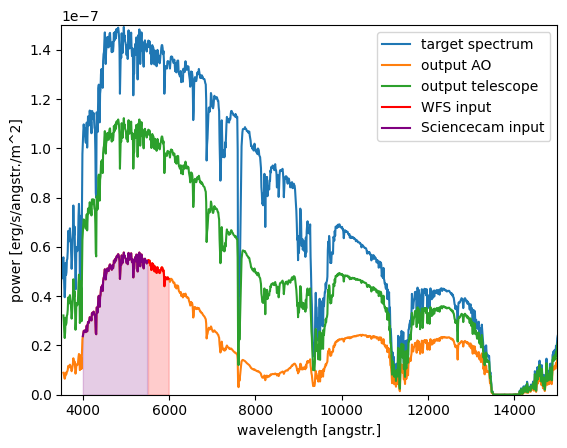

In [12]:
plt.plot(target_wavelength, target_power, label = 'target spectrum')
plt.plot(wavelength_crop2, transmitted_power_ao, label = 'output AO')
plt.plot(wavelength_crop1, transmitted_power_telescope, label='output telescope')
plt.plot(wfs_wls, wfs_power, color='red', label = 'WFS input')
plt.fill_between(wfs_wls, wfs_power, color = 'red', alpha=0.2)
plt.plot(sci_wls, sci_power, color = 'purple', label = 'Sciencecam input')
plt.fill_between(sci_wls, sci_power, color = 'purple', alpha=0.2)
plt.plot()
plt.legend()
plt.xlabel('wavelength [angstr.]')
plt.ylabel('power [erg/s/angstr./m^2]')
plt.xlim(3500, 15000)
plt.ylim(0,1.5e-7)

In [13]:
# make focal plane for science camera

spatial_res = 1.22 * sci_max * focal_length / telescope_diameter # all variables use meters
num_airy = fov_sci/platescale / spatial_res
sci_cam_px_size = 2.9e-6 # [m / px] -- assuming pixel size of current LEO camera on ZimMAIN
q = math.ceil(spatial_res / sci_cam_px_size) # q = number of pixels between rings, num_airy = number of rings that should be visible

focal_grid_sci = make_focal_grid(q=q, num_airy=num_airy, spatial_resolution=spatial_res)

n_pixels_sci = len(focal_grid_sci.coords[0])
print(f'{n_pixels_sci=}px, along one side: {np.sqrt(n_pixels_sci)}px')
print(f"expected number of visible airy disks: {round(num_airy,1)}, expected spatial extent of focal plane: {round(spatial_res*num_airy/1e-6, 1)}µm, pixels per spot: {q}")

n_pixels_sci=2116px, along one side: 46.0px
expected number of visible airy disks: 11.6, expected spatial extent of focal plane: 54.3µm, pixels per spot: 2


In [14]:
prop = FraunhoferPropagator(pupil_grid, focal_grid_sci, focal_length=focal_length)

In [15]:
# put a camera in the Science beam

sci_camera = NoiselessDetector(focal_grid_sci) # uncorrected beam
sci_camera2 = NoiselessDetector(focal_grid_sci) # AO corrected beam

sci_exp_time = 1 # seconds

In [16]:
h = 6.626e-27 # erg * s
c = 3e5 * 1e13 # Angstrom / s

In [17]:
# propagate wavefront from pupil to focal plane (for the Science beam) - once without atmosphere, once with it

counts_per_angstr_ref = np.zeros((len(sci_wavefronts), n_pixels_sci))
counts_per_angstr_calm = np.zeros((len(sci_wavefronts), n_pixels_sci))
counts_per_angstr_turb = np.zeros((len(sci_wavefronts), n_pixels_sci))

photon_counts_total = []

for i, wf in enumerate(sci_wavefronts):

    E_photon = h * c / (wf.wavelength*1e10) # [erg]

    prop_wf = prop.forward(wf)

    accumulated_energy = prop_wf.power * sci_exp_time # [erg * angstr^-1] -- this is 
    counts_per_angstr_ref[i] = accumulated_energy / E_photon # [counts/angstr]

    # without atmosphere - this will be used later as reference-PSF to compute the Strehl ratio in AO simulation
    sci_camera.integrate(prop_wf, sci_exp_time) 
    data1 = sci_camera.read_out() # [erg * angstr^-1]
    counts_per_angstr_calm[i] = data1 / E_photon
    
    # with atmosphere
    sci_camera2.integrate(prop.forward(layer(wf)), sci_exp_time)
    data2 = sci_camera2.read_out()
    counts_per_angstr_turb[i] = data2 / E_photon 

    photon_counts_total.append(np.sum(data1 / E_photon))

photon_in_cam = integrate.simpson(photon_counts_total, sci_wls)
print(f'Expecting {round(photon_in_cam*1e-6, 2)}e6 photons/s in the Science Camera at {int(sci_min*1e10)}-{int(sci_max*1e10)} Angstroms, {round(photon_in_cam/n_pixels_sci,1)} photons per px.')

photon_counts_calm = Field(np.zeros(len(counts_per_angstr_ref[0])), focal_grid_sci)
photon_counts_turb = Field(np.zeros(len(counts_per_angstr_ref[0])), focal_grid_sci)
photon_counts_ref = Field(np.zeros(len(counts_per_angstr_ref[0])), focal_grid_sci)

for i in range(len(counts_per_angstr_ref[0])): # for each pixel, integrate photon count over all wavelengths
    photon_counts_ref[i] = integrate.simpson(counts_per_angstr_ref[:, i], sci_wls)
    photon_counts_calm[i] = integrate.simpson(counts_per_angstr_calm[:, i], sci_wls)
    photon_counts_turb[i] = integrate.simpson(counts_per_angstr_turb[:, i], sci_wls)


Expecting 16.82e6 photons/s in the Science Camera at 4000-5500 Angstroms, 7950.7 photons per px.


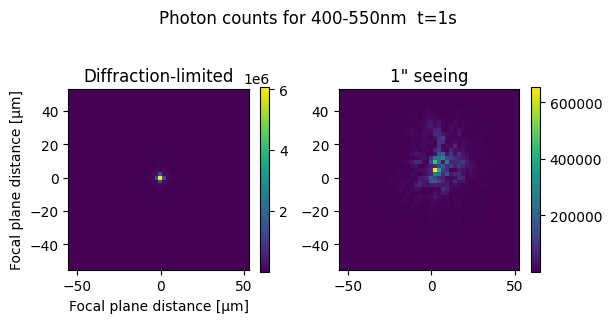

In [18]:
plt.suptitle(f'Photon counts for {int(sci_min*1e9)}-{int(sci_max*1e9)}nm  t={round(sci_exp_time,3)}s', y= 0.85)

plt.subplot(1,2,1)
plt.title('Diffraction-limited')
imshow_field(photon_counts_calm, grid_units=1e-6)
plt.xlabel('Focal plane distance [µm]')
plt.ylabel('Focal plane distance [µm]')
plt.colorbar(shrink=0.5)

plt.subplot(1,2,2)
plt.title(f'{seeing}" seeing')
imshow_field(photon_counts_turb, grid_units=1e-6)
plt.colorbar(shrink=0.5)

plt.show()

In [19]:
strehl = get_strehl_from_focal(photon_counts_turb, photon_counts_calm)
print(f'Seeing-limited Strehl: {strehl}')

Seeing-limited Strehl: 0.029021303146718375


In [20]:
# set SH-WFS parameters

wavelength_percentile_to_scale = 0.5 # which wavelength percentile we want calculate spot size for - 0 (bluest), 1 (reddest), 0.5 (mean)
wlen_to_scale = wfs_min + wfs_bandwidth*wavelength_percentile_to_scale

diff_limit_telescope = 1.22 * wlen_to_scale / telescope_diameter * 206265 # [arcsec]
spot_size_telescope = diff_limit_telescope / platescale # [m]

diff_limit_wfs = diff_limit_telescope * num_lenslets # [arcsec]
n_px_one_spot = round(diff_limit_wfs / px_scale,0)
spot_size_wfs = n_px_one_spot * px_size # [m]

wfs_diameter = px_size * px_per_subap * num_lenslets 
lenslet_diameter = px_size * px_per_subap 
magnification_pupil = wfs_diameter / telescope_diameter 

f_coll = focal_length * magnification_pupil 

magnification_focal = spot_size_wfs / spot_size_telescope

f_wfs = f_coll * magnification_focal
f_number = f_wfs / wfs_diameter
platescale_wfs = platescale / magnification_focal

print(f'''        {fried_parameter=:.2f}m
        {num_lenslets=}
        {px_per_subap=}
        {diff_limit_wfs=:.2f}"
        {f_number=:.2f}
        {fov_wfs=:.2f}"
        {wfs_diameter=:f}m
        {wlen_to_scale=}m
        {spot_size_wfs=}m
        {magnification_pupil=}
        {n_px_one_spot=}
        {px_scale=}"/px''')

        fried_parameter=0.10m
        num_lenslets=8
        px_per_subap=7.0
        diff_limit_wfs=1.45"
        f_number=68.42
        fov_wfs=5.00"
        wfs_diameter=0.001344m
        wlen_to_scale=5.75e-07m
        spot_size_wfs=4.8e-05m
        magnification_pupil=0.00168
        n_px_one_spot=2.0
        px_scale=0.75"/px


In [21]:
# make a SH-WFS using above parameters

magnifier = Magnifier(magnification_pupil)

shwfs = MySquareShackHartmannWavefrontSensorOptics(pupil_grid.scaled(magnification_pupil), 
                                                 f_number, 
                                                 num_lenslets, 
                                                 wfs_diameter)

# I wrote a separate SHWFS class so that the MLA does not center the central lenslet row right onto the spiders which obscure them
# This new class also fixes a bug in their code where the MLA diameter is double the pupil diameter.


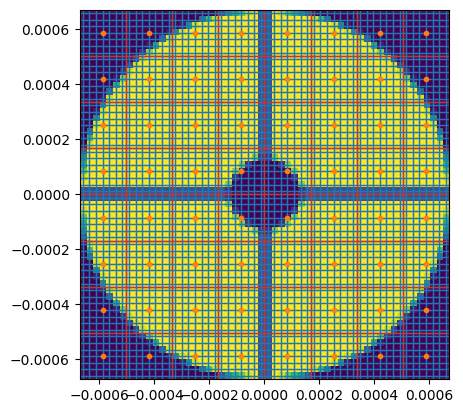

In [22]:
# plot SH-WFS

pupil_aperture_generator_wfs = make_obstructed_circular_aperture(telescope_diameter*magnification_pupil, 
                                                             central_obscuration_ratio, 
                                                             num_spiders=num_spiders, 
                                                             spider_width=spider_width*magnification_pupil)

grid2 = pupil_grid.scaled(magnification_pupil)
plt.plot(grid2.x, grid2.y, '+', label = 'scaled pupil grid')
imshow_field(evaluate_supersampled(pupil_aperture_generator_wfs, grid2, 4))
grid = shwfs.mla_grid 
for p in grid.points:
    d = grid.x[1]-grid.x[0]
    rect = plt.Rectangle(p - d/ 2, d, d, linewidth=1, edgecolor=colors.red, facecolor='none')
    plt.gca().add_patch(rect)
plt.plot(shwfs.mla_grid.x, shwfs.mla_grid.y, '.', label = 'MLA')
plt.gca().set_aspect(1)
plt.show()

In [23]:
# put a camera behind the WFS, choose its exposure time

focal_grid_wfs = pupil_grid.scaled(magnification_pupil)
n_pixels_wfs = int(len(focal_grid_wfs.coords[0]))
print(n_pixels_wfs)
camera = NoiselessDetector(focal_grid_wfs)

operation_freq = 1e3 # [Hz]
wfs_exp_time = 1 / operation_freq

3136


In [24]:
# read out WFS image, once without atmosphere, then with 

# the wavefront electric field is defined on the pupil grid, it's value is the sqrt of the power
# when sent through the magnifier, wavefront electic field is redefined on the magnified pupil grid 
# and the wavefront electric field is divided by sqrt(magnification)

counts_per_angstr_ref = np.zeros((len(wfs_wavefronts), n_pixels_wfs))
counts_per_angstr_calm = np.zeros((len(wfs_wavefronts), n_pixels_wfs))
counts_per_angstr_turb = np.zeros((len(wfs_wavefronts), n_pixels_wfs))

photon_counts_total = []

for i, wf in enumerate(wfs_wavefronts):

    E_photon = h * c / (wf.wavelength*1e10) # [erg]

    # without atmosphere
    camera.integrate(shwfs(magnifier(wf)), wfs_exp_time)
    data1 = camera.read_out() # [erg * angstr^-1]
    counts_per_angstr_calm[i] = data1 / E_photon

    # reference image - this will be used later to compute the Strehl ratio in AO simulation
    counts_per_angstr_ref[i] = counts_per_angstr_calm[i] / wfs_exp_time
    
    # with atmosphere
    camera.integrate(shwfs(magnifier(layer(wf))), wfs_exp_time)
    data2 = camera.read_out()
    counts_per_angstr_turb[i] = data2 / E_photon 

    photon_counts_total.append(np.sum(data1 / E_photon))

photon_in_cam = integrate.simpson(photon_counts_total, wfs_wls)
print(f'Expecting {round(photon_in_cam*1e-6, 2)}e6 photons/s in the WFS at {int(wfs_min*1e10)}-{int(wfs_max*1e10)} Angstroms, {round(photon_in_cam/n_pixels_wfs,1)} photons per px at {operation_freq}Hz.')

photon_counts_calm = Field(np.zeros(len(counts_per_angstr_ref[0])), focal_grid_wfs)
photon_counts_turb = Field(np.zeros(len(counts_per_angstr_ref[0])), focal_grid_wfs)
photon_counts_ref = Field(np.zeros(len(counts_per_angstr_ref[0])), focal_grid_wfs)

for i in range(len(counts_per_angstr_ref[0])): # loop over pixels, integrate all wavelengths
    photon_counts_ref[i] = integrate.simpson(counts_per_angstr_ref[:, i], wfs_wls)
    photon_counts_calm[i] = integrate.simpson(counts_per_angstr_calm[:, i], wfs_wls)
    photon_counts_turb[i] = integrate.simpson(counts_per_angstr_turb[:, i], wfs_wls)

Expecting 0.01e6 photons/s in the WFS at 5500-6000 Angstroms, 2.2 photons per px at 1000.0Hz.


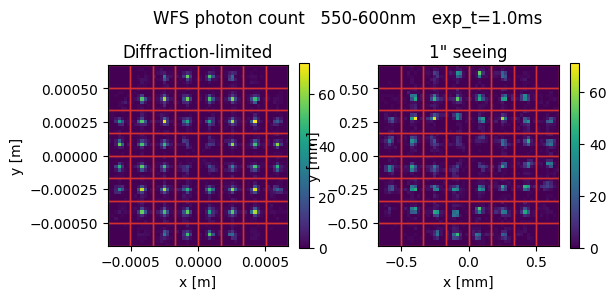

In [25]:
# plot a WFS image example for a perturbed & unperturbed wavefront, both with photon noise

plt.suptitle(f'WFS photon count   {int(wfs_min*1e9)}-{int(wfs_max*1e9)}nm   exp_t={round(wfs_exp_time*1e3,2)}ms', y= 0.8)

photon_counts_calm = large_poisson(photon_counts_calm).astype('float') 
photon_counts_turb = large_poisson(photon_counts_turb).astype('float') 

plt.subplot(1,2,1)
imshow_field(photon_counts_calm, vmin = 0)#, vmax = np.max(photon_image_calm))
plt.title(f'Diffraction-limited')
plt.gca().set_aspect(1)
plt.xlabel('x [m]')
plt.ylabel('y [m]')
for p in grid.points:
    d = grid.x[1]-grid.x[0]
    rect = plt.Rectangle(p - d/ 2, d, d, linewidth=1, edgecolor=colors.red, facecolor='none')
    plt.gca().add_patch(rect)
plt.colorbar(shrink=0.5)

plt.subplot(1,2,2)
imshow_field(photon_counts_turb, grid_units=1e-3, vmin = 0)#, vmax = np.max(photon_image_calm))
plt.title(f'{seeing}" seeing')
plt.gca().set_aspect(1)
plt.xlabel('x [mm]')
plt.ylabel('y [mm]')
for p in grid.points:
    d = (grid.x[1]-grid.x[0])*1e3
    rect = plt.Rectangle(p*1e3 - d/ 2, d, d, linewidth=1, edgecolor=colors.red, facecolor='none')
    plt.gca().add_patch(rect)
plt.colorbar(shrink=0.5)

In [26]:
# pick which subapertures are illuminated enough to actually use

cutoff_below = 0.75

shwfse = ShackHartmannWavefrontSensorEstimator(shwfs.mla_grid, shwfs.micro_lens_array.mla_index)

fluxes = ndimage.measurements.sum(photon_counts_ref, shwfse.mla_index, shwfse.estimation_subapertures)
flux_limit = fluxes.max() * cutoff_below

estimation_subapertures = shwfs.mla_grid.zeros(dtype='bool')
estimation_subapertures[shwfse.estimation_subapertures[fluxes > flux_limit]] = True

shwfse = ShackHartmannWavefrontSensorEstimator(shwfs.mla_grid, shwfs.micro_lens_array.mla_index, estimation_subapertures)

print(f'Using {len(shwfse.estimation_subapertures)}/{num_lenslets**2} subapertures for slope estimation.')
print(f'Avg. photon count per (illuminated) subaperture: {round(np.mean(ndimage.measurements.sum(photon_counts_ref, shwfse.mla_index, shwfse.estimation_subapertures)),1)}')


Using 40/64 subapertures for slope estimation.
Avg. photon count per (illuminated) subaperture: 142091.3


/var/folders/c6/3j4rmdms4vbfk4qv_kpw36_h0000gn/T/ipykernel_5498/3330397884.py:7: DeprecationWarning: Please import `sum` from the `scipy.ndimage` namespace; the `scipy.ndimage.measurements` namespace is deprecated and will be removed in SciPy 2.0.0.
  fluxes = ndimage.measurements.sum(photon_counts_ref, shwfse.mla_index, shwfse.estimation_subapertures)
/var/folders/c6/3j4rmdms4vbfk4qv_kpw36_h0000gn/T/ipykernel_5498/3330397884.py:16: DeprecationWarning: Please import `sum` from the `scipy.ndimage` namespace; the `scipy.ndimage.measurements` namespace is deprecated and will be removed in SciPy 2.0.0.
  print(f'Avg. photon count per (illuminated) subaperture: {round(np.mean(ndimage.measurements.sum(photon_counts_ref, shwfse.mla_index, shwfse.estimation_subapertures)),1)}')


In [27]:
# get slopes for the unperturbed wavefront 

slopes_ref = shwfse.estimate([photon_counts_ref]) # can I use photon counts as a unit for slope estimation?

In [28]:
# choose number of actuators for DM <-> select number of correctable AO modes

num_actuators = (telescope_diameter/fried_parameter)**2
num_modes = int(round(num_actuators,0))
print(f'Allowing for {num_modes} modes at {seeing}" seeing.')

dm_modes = make_zernike_basis(num_modes=num_modes, 
                              D=telescope_diameter,
                              grid=pupil_grid, 
                             use_cache=False) # btw: harmonic disk basis uses fourier bessel basis functions
dm_modes = ModeBasis([mode / np.ptp(mode) for mode in dm_modes], pupil_grid)

Allowing for 63 modes at 1" seeing.


In [29]:
deformable_mirror = DeformableMirror(dm_modes)

In [30]:
# calibrate interaction matrix 
# for this, excite each mode individually and log what happens to the centroids on the detector

probe_amp = 0.5 * telescope_diameter / 2 * np.sin(fov_wfs/3600) * magnification_pupil # [m] -- stroke of DM
print(f'DM has stroke {probe_amp}m')
response_matrix = []

wf = Wavefront(telescope_pupil, wavelength_wfs)
wf.total_power = 1

# Set up animation
fig = plt.figure(figsize=(10, 6))
writer = FFMpegWriter(
    fps=2,
    metadata={"title": "DM Interaction Matrix Calibration"},
    bitrate=1800
)
output_file = "interaction_matrix_calibration.mp4"

deformable_mirror.flatten()

with writer.saving(fig, output_file, dpi=100):

    for i in tqdm(range(num_modes)):
        slope = 0
    
        # Probe the phase response
        amps = [-probe_amp, probe_amp]
        for amp in amps:
            deformable_mirror.flatten()
            deformable_mirror.actuators[i] = amp
    
            dm_wf = deformable_mirror.forward(wf)
            wfs_wf = shwfs(magnifier(dm_wf))

            camera.integrate(wfs_wf, 1)
            image = camera.read_out()
    
            slopes = shwfse.estimate([image])
    
            slope += amp * slopes / np.var(amps)
    
        response_matrix.append(slope.ravel())
    
        # Only show all modes for the first 40 modes
        if i > 40 and (i + 1) % 20 != 0:
            continue
    
        # Plot mode response
        plt.clf()
        plt.suptitle('Mode %d / %d' % (i + 1, num_modes), y=0.87)
    
        plt.subplot(1,2,1)
        plt.title('DM surface')
        im1 = imshow_field(deformable_mirror.surface, cmap='RdBu', mask=telescope_pupil)
    
        plt.subplot(1,2,2)
        plt.title('SH spots (slopes not to scale)')
        im2 = imshow_field(image)
        plt.quiver(shwfs.mla_grid.subset(shwfse.estimation_subapertures).x,
            shwfs.mla_grid.subset(shwfse.estimation_subapertures).y,
            slope[0,:], slope[1,:],
            color='white')
    
        writer.grab_frame()

response_matrix = ModeBasis(response_matrix)

plt.close(fig)
print(f"Animation saved to: {output_file}")

DM has stroke 4.6666651663238765e-07m


  0%|          | 0/63 [00:00<?, ?it/s]

Animation saved to: interaction_matrix_calibration.mp4


In [31]:
# invert the response matrix to get a function that takes slope as input and gives actuator movement as output

rcond = 1e-3

reconstruction_matrix = inverse_tikhonov(response_matrix.transformation_matrix, rcond=rcond)

In [32]:
# Close the loop, with atmosphere

layer.reset()
deformable_mirror.flatten()

t_atmos = 0.001 # this is not the coherence time tau, just the update frequency of atmospheric plots
sci_exp_time = 0.006 # 0.006s -> 150fps for LEO

include_photon_noise = True

gain = 0.02 # somewhere between 0.0075 and 0.02, depending on seeing
leakage = 0.01

num_iterations = 150 # corresponds to [ms] if the atmosphere is set to evolve at 1ms speed
playback_speed = 0.1

fig = plt.figure(figsize=(12, 8))
writer = FFMpegWriter(
    fps=int(playback_speed / t_atmos),
    metadata={"title": "Closing the Loop with turbulent atmosphere"},
    bitrate=1800
)
output_file = f"Animations/AO_{int(operation_freq)}Hz_WFS{int(wfs_min*1e10)}A_{int(wfs_max*1e10)}A_Sci{int(sci_min*1e10)}A_{int(sci_max*1e10)}A_BS{int(wfs_beamsplit*100)}pct_SC{sci_exp_time}s_exptime_r0{int(fried_parameter*1e2)}cm_gain{gain}_stroke{round(probe_amp*1e6,2)}microns_{num_iterations}iter_photonnoise_{include_photon_noise}.mp4"

strehls = []
strehls_uncorr = []

wfs_energy = 0
wfs_photon_image = 0
counts_per_angstr_turb = np.zeros((len(wfs_wavefronts), n_pixels_wfs))
photon_counts_turb = Field(np.zeros(len(counts_per_angstr_ref[0])), focal_grid_wfs)


with writer.saving(fig, output_file, dpi=100):
    
    for timestep in tqdm(range(num_iterations)):

        # atmosphere evolution
        layer.t = timestep * t_atmos
        phase_screen_phase = layer.phase_for(wavelength_wfs) # [rad]
        phase_screen_opd = phase_screen_phase * (wavelength_wfs / (2 * np.pi)) * 1e6 # [µm]
    
        # WFS image capture
        for i, wf in enumerate(wfs_wavefronts):

            E_photon = h * c / (wf.wavelength*1e10) # [erg]
            camera.integrate(shwfs(magnifier(deformable_mirror(layer(wf)))), t_atmos) 
            wfs_data = camera.read_out()
            counts_per_angstr_turb[i] = wfs_data / E_photon

        for i in range(len(counts_per_angstr_turb[0])): # for each pixel, integrate photon counts across all wavelengths
            photon_counts_turb[i] += integrate.simpson(counts_per_angstr_turb[:, i], wfs_wls)

        if int(layer.t*10000) % int(wfs_exp_time*10000) == 0:
            wfs_photon_image_to_plot = photon_counts_turb
            photon_counts_turb = Field(np.zeros(len(counts_per_angstr_ref[0])), focal_grid_wfs)

        # Science image capture (corrected and uncorrected)
        psf_ref = 0
        for wf in sci_wavefronts:
            sci_camera.integrate(prop(layer(wf)), t_atmos) # uncorrected
            sci_camera2.integrate(prop(deformable_mirror(layer(wf))), t_atmos) # corrected
            psf_ref += prop.forward(wf).power*sci_exp_time #*prop.forward(wf).wavelength*1e10*5.03e7

        if int(layer.t*1000) % int(sci_exp_time*1000) == 0: # modulo behaves weird with decimals

            psf_uncorr = sci_camera.read_out()
            psf_corr = sci_camera2.read_out()
        
            strehl = float(get_strehl_from_focal(psf_corr, psf_ref))
            strehl_uncorr = float(get_strehl_from_focal(psf_uncorr, psf_ref))
            if timestep/num_iterations > 0.05:# and timestep/num_iterations < 0.95: # cut off weird temporal edge behavior
                strehls.append(strehl)
                strehls_uncorr.append(strehl_uncorr)
                
                    
        # Calculate slopes from WFS image
        if include_photon_noise:
            wfs_photon_image_to_plot = large_poisson(wfs_photon_image_to_plot).astype('float')
        slopes = shwfse.estimate([wfs_photon_image_to_plot + 1e-20])
        slopes -= slopes_ref
        slopes = slopes.ravel()
    
        # Set DM actuators
        deformable_mirror.actuators = (1 - leakage) * deformable_mirror.actuators - gain * reconstruction_matrix.dot(slopes)

        # plot: atmosphere, DM, WFS image, corr focal image, uncorr focal image
        if timestep % 1 == 0: # can make this plotting frequency more coarse if needed
            plt.clf()
    
            plt.suptitle(f'Gain: {gain}  PSF at $\\lambda$={round(wavelength_sci*1e6,2)}µm  WFS at $\\lambda$={round(wavelength_wfs*1e6,2)}µm  DM stroke: {round(probe_amp*1e6,2)}µm  WFS freq = {operation_freq}Hz  t = {round(layer.t,3)}  S={round(strehl,2)}', y = 0.92)
            plt.subplots_adjust(wspace=0.5) 
            
            plt.subplot(2,3,1)
            plt.title('DM OPD [$\\mu$m]')
            imshow_field(deformable_mirror.surface * 1e6, cmap='RdBu', vmin=-6, vmax=6, mask=telescope_pupil)
            plt.colorbar()
            plt.xlabel('x [m]')
            plt.ylabel('y [m]')
    
            plt.subplot(2,3,2)
            plt.title('WFS image [counts]')
            imshow_field(wfs_photon_image_to_plot, vmin=0, vmax=np.max(wfs_photon_image_to_plot), grid_units=1e-3)
            plt.colorbar()
            for p in grid.points:
                d = (grid.x[1]-grid.x[0])*1e3
                rect = plt.Rectangle(p*1e3 - d/ 2, d, d, linewidth=1, edgecolor=colors.red, facecolor='none')
                plt.gca().add_patch(rect)
            plt.xlabel('x [mm]')
            plt.ylabel('y [mm]')
    
            plt.subplot(2,3,3)
            plt.title(f'AO-Corr. PSF $\\mu$m [log]')
            imshow_field(np.log10(psf_corr/psf_corr.max()), vmin=-5, vmax=0, grid_units=1e-6) 
            plt.colorbar()
            plt.xlabel('x [µm]')
            plt.ylabel('y [µm]')

            plt.subplot(2,3,4)
            plt.title(f'Uncorr. PSF $\\mu$m [log]')
            imshow_field(np.log10(psf_uncorr/psf_uncorr.max()), vmin=-5, vmax=0, grid_units=1e-6) 
            plt.colorbar()
            plt.xlabel('x [µm]')
            plt.ylabel('y [µm]')

            plt.subplot(2,3,5)
            plt.title('Atmosph. OPD [$\\mu$m]')
            imshow_field(phase_screen_opd, vmin=-6, vmax=6, cmap='RdBu')
            plt.colorbar()
            plt.xlabel('x [m]')
            plt.ylabel('y [m]')
            

        writer.grab_frame()
        
plt.close(fig)
print(f"Animation saved to: {output_file}")

# calculate average Strehls
strehl_ao = np.mean(strehls)
strehl_noao = np.mean(strehls_uncorr)

# save results 
fields=['seeing', 'r0', 'v', 'n_actuators', 'n_lenslets', 'SH_FOV', 'WFS_exp_time', 'WFS_lambda_min', 'WFS_lambda_max',
        'SC_exp_time', 'SC_lambda_min', 'SC_lambda_max', 'beamsplit', 'DM_stroke', 'photon_noise', 'Strehl_noAO', 'Strehl_AO']   

new_row = {'seeing': seeing,
           'r0': fried_parameter, 
           'v': velocity, 
           'n_actuators': num_actuators,
           'n_lenslets': num_lenslets,
           'SH_FOV': fov_wfs,
           'WFS_exp_time': wfs_exp_time, 
           'WFS_lambda_min': wfs_min, 
           'WFS_lambda_max': wfs_max, 
           'SC_exp_time': sci_exp_time, 
           'SC_lambda_min': sci_min, 
           'SC_lambda_max': sci_max, 
           'beamsplit': wfs_beamsplit, 
           'DM_stroke': probe_amp,
           'photon_noise': include_photon_noise,
           'Strehl_noAO': strehl_noao, 
           'Strehl_AO': strehl_ao}

with open('ao_performance.txt', 'a') as f:
    writer = DictWriter(f, fieldnames=fields)
    writer.writerow(new_row)

  0%|          | 0/150 [00:00<?, ?it/s]

Animation saved to: Animations/AO_1000Hz_WFS5500A_6000A_Sci4000A_5500A_BS100pct_SC0.006s_exptime_r010cm_gain0.02_stroke0.47microns_150iter_photonnoise_True.mp4
